# Toy Model: Analysis

In [1]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import pickle
import pandas as pd
from scipy import stats


# my preferred settings
mpl.rc('lines',linewidth = 1.5)
mpl.rc('font',size = 14)
mpl.rc('axes',labelsize = 16, linewidth=1.25)
mpl.rc('xtick',labelsize = 16)
mpl.rc('ytick',labelsize = 16)
# enable math fonts
mpl.rc('mathtext', default = 'regular')
plt.rcParams['savefig.dpi'] = 400 

from sbin.complexity import gap_complexity, ecdf_confidence
import seaborn as sns 

from sbin.SuppressionSimulator import SuppressionSimulator
from sbin.simulation_helper import run_trials
from sbin.plotting_utilities import plot_semimajor, plot_semimajor_ecdf, ecdf_grid


sup_method='simple'

if sup_method=='simple':
    from sbin.suppression_utilities import suppression_factor_simple as my_suppression_factor
elif sup_method=='moekratter':
    from sbin.suppression_utilities import suppression_factor as my_suppression_factor
elif sup_method=='50':
     from sbin.suppression_utilities import suppression_factor_50 as my_suppression_factor   
else:
    raise




### Read in data saved from Filtering

In [2]:
with open("filtered_data.pkl", "rb") as f:
     data = pickle.load(f)
              
close = data["close"]
good = data["good"]
db_filtered = data["db_filtered"]
kois_filtered = data["kois_filtered"]
kois_good = data["kois_good"]
cks_filtered = data["cks_filtered"]
cks_good = data["cks_good"]

with open("filtered_data_thebault.pkl", "rb") as f:
     tb_filtered = pickle.load(f)['db_filtered']

In [3]:
# separation values (as lists) for each star in binary sample
tmp = db_filtered.groupby('KOI')['SepAU'].agg('unique')
binary_separations_sullivan = np.concatenate(tmp.to_numpy())

tmp = tb_filtered.groupby('Alternate')['semi-major'].agg('unique')
binary_separations_tb = np.concatenate(tmp.to_numpy())


# Toy Model

### Suppress the KOIs

In [4]:

# ------------------------------------------------------------------
#  Initialise the simulator
# ------------------------------------------------------------------
sim = SuppressionSimulator(
    planets_cat=kois_filtered,
    sup_function=my_suppression_factor,
    sup_type="planets",
    join_on="KOI",
    prad_col="koi_prad",
    random_state=42,               # <‑‑ makes the run deterministic
)

# ------------------------------------------------------------------
#  Run it
# ------------------------------------------------------------------
res_systems, res_planets  = run_trials(
    simulator=sim,
    n_trials=10)

## Semi-major axis plots

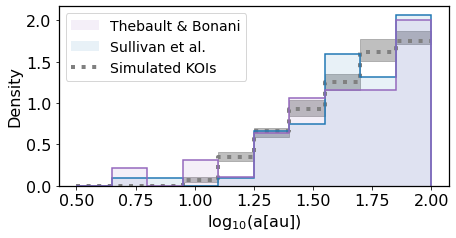

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
bins = plot_semimajor(ax, res_systems.survived_semimajor_by_system)

plt.hist(np.log10(binary_separations_sullivan), 
         density=True, bins=bins, histtype='step',
         color='C0', alpha=1, lw=1.5)
plt.hist(np.log10(binary_separations_sullivan), 
         density=True, bins=bins, histtype='stepfilled',
         color='C0', alpha=0.1, label='Sullivan et al.')

plt.hist(np.log10(binary_separations_tb), 
         density=True, bins=bins, histtype='step',
         color='C4', alpha=1, lw=1.5)
plt.hist(np.log10(binary_separations_tb), 
         density=True, bins=bins, histtype='stepfilled',
         color='C4', alpha=0.1, label='Thebault & Bonani')

handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.gca().legend(handles[::-1], labels[::-1], loc='upper left')

plt.savefig('kois_loga_'+sup_method+'.png')

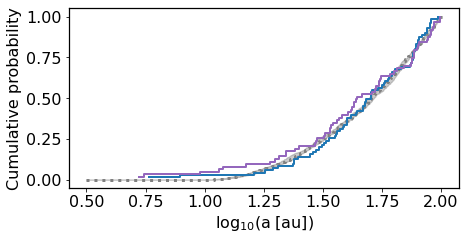

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
plot_semimajor_ecdf(ax, res_systems.survived_semimajor_by_system)

log_obs = np.log10(binary_separations_sullivan)   # work in log10 just like the sims
xs_obs, ys_obs = ecdf_grid(log_obs[log_obs<2])
plt.step(xs_obs, ys_obs, where='post',
        color='C0', lw=2, linestyle='-', label='Sullivan et al.')

log_obs = np.log10(binary_separations_tb)   # work in log10 just like the sims
xs_obs, ys_obs = ecdf_grid(log_obs[log_obs<2])
plt.step(xs_obs, ys_obs, where='post',
        color='C4', lw=2, linestyle='-', label='Thebault & Bonani')


In [ ]:

def compare_observed_vs_simulated(
    a_obs,
    a_sim_trials,
    completeness_func=None,
    n_boot=5000,
    plot=True,
    seed=42,
):
    """
    Parameters
    ----------
    a_obs : 1‑D array (AU) – observed semi‑major axes.
    a_sim_trials : 2‑D array (n_trials, n_per_trial) – simulated axes.
    completeness_func : function a → detection probability (default: no filter).
    n_boot : int – # bootstrap replicates for KS distance CI.
    plot : bool – generate diagnostic plots.
    seed : int – reproducibility.
    Returns
    -------
    dict with
        ks_p_pp, ad_p_pp, energy_p_pp, ks_ci, ks_dist_obs,
        ks_dist_trials, ad_dist_trials, energy_dist_trials
    """
    rng = np.random.default_rng(seed)
    
    log_obs   = np.log10(a_obs[a_obs<100.])

    # -------------------------------------------------
    # 6.2  Distance metrics for each trial
    # -------------------------------------------------
    ks_trials    = np.empty(len(a_sim_trials))
    ad_trials    = np.empty(len(a_sim_trials))

    for i, trial in enumerate(a_sim_trials):
        log_sim  = np.log10(trial[trial<100.])   # shape (T, N_sim)
        ks_trials[i]    = stats.ks_2samp(log_obs, log_sim).pvalue
        ad_trials[i]    = stats.anderson_ksamp([log_obs, log_sim]).statistic
        
    print(np.percentile(ks_trials, q=[16,50,84]))
    print(np.percentile(ad_trials, q=[16,50,84]))

    
compare_observed_vs_simulated(binary_separations_sullivan, res_systems.survived_semimajor_by_system)
compare_observed_vs_simulated(binary_separations_tb, res_systems.survived_semimajor_by_system)

## Multiplicity plots

NameError: name 'st' is not defined

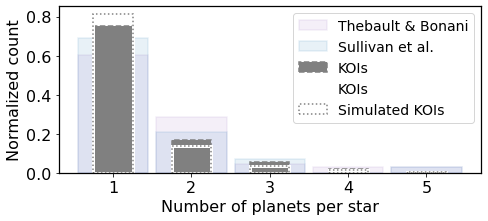

In [8]:
def multiplicity_hist(sim_results):
    
    sim_npl = np.ones((ntrials, 5))
    for i,vv in enumerate(sim_results):
        nstars = len(vv)
        ww = 1./np.full(nstars, nstars, dtype=float)
        hist, _ = np.histogram(vv, weights=ww, 
                               bins=[0.5,1.5,2.5,3.5,4.5,5.5])
        sim_npl[i] = hist
    y = np.percentile(sim_npl, q=50, axis=0)
    
    return y

# Planet counts
close = tb_filtered['semi-major']<100.
tb_planet_counts = tb_filtered[close].groupby('KOI').size().reset_index(name='n_planets')
koi_planet_counts = kois_filtered.groupby('KOI').size().reset_index(name='n_planets')

close = db_filtered['SepAU']<100.
sullivan_planet_counts = db_filtered[close].groupby('KOI').size().reset_index(name='n_planets')
        
        
fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
x = np.array([1,2,3,4,5])


nstars = len(tb_planet_counts)
ww = 1./np.full(nstars, nstars, dtype=float)
y, _ = np.histogram(tb_planet_counts['n_planets'], 
                    weights=ww, bins=[0.5,1.5,2.5,3.5,4.5,5.5])
ax.bar(x, y, edgecolor='C4', facecolor='C4', alpha=0.1, 
            width=0.9, linewidth=1.5, label='Thebault & Bonani')

nstars = len(sullivan_planet_counts)
ww = 1./np.full(nstars, nstars, dtype=float)
y, _ = np.histogram(sullivan_planet_counts['n_planets'], 
                    weights=ww, bins=[0.5,1.5,2.5,3.5,4.5,5.5])
ax.bar(x, y, edgecolor='C0', facecolor='C0', alpha=0.1,
            width=0.9, linewidth=1.5, label='Sullivan et al.')


## add raw planet counts

nstars = len(koi_planet_counts)
ww = 1./np.full(nstars, nstars, dtype=float)
y, _ = np.histogram(koi_planet_counts['n_planets'], 
                    weights=ww, bins=[0.5,1.5,2.5,3.5,4.5,5.5])
ax.bar(x, y, ls='--', edgecolor='gray', facecolor='gray',  
            width=0.5, lw=1.5, label='KOIs')


## panel for suppressed planet counts

nstars = len(res_planets.planet_counts_per_system)
ww = 1./np.full(nstars, nstars, dtype=float)
y, _ = np.histogram(res_planets.planet_counts_per_system['n_planets'], 
                    weights=ww, bins=[0.5,1.5,2.5,3.5,4.5,5.5])
ax.bar(x, y, ls='-', edgecolor='w', facecolor='none',  
            width=0.5, lw=3, label='KOIs')

ax.bar(x, y, ls=':', edgecolor='gray', facecolor='none',  
            width=0.5, lw=1.5, label='Simulated KOIs')


plt.xlabel('Number of planets per star')
plt.ylabel('Normalized count')
plt.legend()
plt.tight_layout()



# Statistics

print(st.mannwhitneyu(close_planet_counts['n_planets'], koi_planet_counts['n_planets'], alternative='two-sided'))

results = [st.mannwhitneyu(close_planet_counts['n_planets'], x, alternative='two-sided') for x in koi_npl_sim]
results = np.asarray(results, dtype=float)   # shape = (Nsim, 2)

U_stats = results[:, 0]      # array of U‑statistics
p_values  = results[:, 1]      # array of p‑values
print(np.percentile(p_values, q=[16,50,84]))

return fig
